# Assignment 2 – Zero-Shot Image Classification with Transformers

In this assignment, you will apply a pre-trained vision–language transformer (e.g. CLIP) to perform **zero-shot** classification on the Fashion-MNIST dataset—classifying each image without any task-specific training. You will build on the concepts from Assignment 1 by comparing this “off-the-shelf” approach to the CNN you previously trained.

You will:
1. **Load** the Fashion-MNIST images using PyTorch instead of Keras.
2. **Run a zero-shot baseline** with simple text prompts to set a performance reference.
3. **Engineer improved prompts** and measure the resulting accuracy gains.
4. **Visualise image embeddings** with UMAP to inspect class separability.
5. **Conduct one mini-experiment** of your choice.
6. **Summarise findings** and reflect on strengths and weaknesses of zero-shot transformers versus a trained CNN.

# 1. Loading the Fashion-MNIST Dataset

As in assignment 1, we'll load the Fashion-MNIST dataset, but this time using `torchvision.datasets` to ensure compatibility with the `transformers` library. We will also load our model and processor from the `transformers` library.

The transformers library allows us to use pre-trained models like CLIP, which can perform zero-shot classification by leveraging the text prompts we provide. There are two key objects we will use: the `CLIPModel` for the model itself and the `CLIPProcessor` for preparing our images and text prompts.

Since we are not actually training a model in this assignment, we will set the CLIP model to evaluation mode. If the model is designed to utilize features like dropout or batch normalization, setting it to evaluation mode ensures that these features behave correctly during inference (prediction). Setting the model to evaluaton mode also tells PyTorch that we don't have to compute gradients, which can save memory and speed up inference.

In order to speed up processing, we will also move the model to an "accelerator" if available. This is typically a GPU, but modern MacBooks also have an "Apple Silicon" accelerator that can be used for inference, called MPS (Metal Performance Shaders). If you are using a MacBook with Apple Silicon, you can use the MPS device for faster processing.

In [10]:
# Uncomment and run if required
!pip install transformers torchvision torch accelerate


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [11]:
from transformers import CLIPModel, CLIPProcessor
import torch

clip_model_name = "openai/clip-vit-base-patch32"
clip_model     = CLIPModel.from_pretrained(clip_model_name)
clip_processor = CLIPProcessor.from_pretrained(clip_model_name, use_fast=False)

# Set model to evaluation mode, as we are not training it
clip_model.eval()

# Check for accelerators
device = "cpu" # Default to CPU
if torch.cuda.is_available():
    device = "cuda" # Use GPU if available
elif torch.backends.mps.is_available():
    device = "mps"

clip_model.to(device)

print(f"Using device: {device}")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using device: mps


Now we are ready to load the testing set from Fashion-MNIST. We will use the `torchvision.datasets.FashionMNIST` class to load the dataset. We do not need to apply any transformations to the images, as the `CLIPProcessor` ensures any input images are in the format that the model is trained on.

You should:

- [ ] Use the `torchvision.datasets.FashionMNIST` class to load the *test* split of the dataset. Documentation is available [here](https://pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html).
- [ ] Create a PyTorch `DataLoader` to iterate over the dataset in batches. Use a batch size of 16 and set `shuffle=True` to randomise the order of the images. You will also need to supply the provided `collate_clip` function to the `DataLoader collate_fn` argument to ensure the images are processed correctly. Documentation for `DataLoader` is available [here](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader).

In [12]:
from torchvision import datasets
from torch.utils.data import DataLoader

CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

def collate_clip(batch):
    imgs, labels = zip(*batch) # Unzip the batch into images and labels
    proc = clip_processor(images=list(imgs),
                        return_tensors="pt",
                        padding=True) # Process images with CLIPProcessor
    # Send pixel_values to GPU/CPU now; labels stay on CPU for metrics
    return proc["pixel_values"].to(device), torch.tensor(labels)

test_dataset = datasets.FashionMNIST(
    root="./data", 
    train=False,      # Load test split (assignment explicitly said NOT training)
    download=True,    # Download if missing
    transform=None    # CLIPProcessor handles transformations
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,    #  Assignment requirement
    shuffle=True,     #  Assignment requirement
    collate_fn=collate_clip  #  our custom preprocessor
)

If your code is correct, the following cell should show the first batch of images from the Fashion-MNIST dataset:

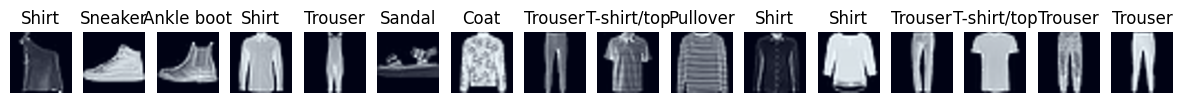

In [13]:
import matplotlib.pyplot as plt

# Display the first batch of images from `test_loader`

def show_batch(loader):
    images, labels = next(iter(loader))
    images = images.cpu()  # Move images to CPU for plotting
    # Renormalize to [0, 1] for visualization
    images = (images - images.min()) / (images.max() - images.min())
    _, axes = plt.subplots(1, len(images), figsize=(15, 5))
    for ax, img, label in zip(axes, images, labels):
        ax.imshow(img.permute(1, 2, 0))
        ax.set_title(CLASS_NAMES[label.item()])
        ax.axis('off')
    plt.show()

show_batch(test_loader)

We’re now ready to run our zero-shot classification baseline!

# Brief Introduction to Zero-Shot Classification

In Assignment 1, we followed the typical machine-learning pipeline: we trained a CNN on the Fashion-MNIST dataset, using labelled examples to update the model’s weights. While effective, that approach requires a curated, task-specific training set—a luxury you don’t always have in practice.

Zero-shot classification flips the script.  A large vision–language model (VLM) such as **CLIP** is first pre-trained on hundreds of millions of image–text pairs scraped from the web.  Because it learns *joint* visual–textual embeddings, the model can later solve new tasks simply by “measuring” how similar an image is to a **text prompt** that describes each candidate class—without seeing a single task-labelled example.

**How it works**  
1. Feed an image through CLIP’s vision encoder → **image feature**.  
2. Feed a textual prompt (e.g. “a photo of a sandal”) through CLIP’s text encoder → **text feature**.  
3. Compute cosine similarity between the image feature and every class’s text feature.  
4. Pick the class whose prompt is most similar.

For our first attempt, we’ll use the bare class names as prompts, e.g.:

- "T-shirt/top"
- "Trouser"

### You should:

- [ ] Build embeddings: use the `get_text_embeddings` helper function to create text embeddings for the class names.
- [ ] Run inference: use the `get_image_embeddings` helper function to create image embeddings.
- [ ] Compute cosine similarity: complete and use the `get_cosine_similarity` helper function to compute the cosine similarity between the image and text embeddings.
- [ ] Make predictions: use the `get_predictions` helper function to get the predicted class for each image in the batch.

Note that for normalized vectors like the ones we are using, cosine similarity is equivalent to the dot product. This means we can use the handy formula `cosine_similarity = vector_a @ vector_b.T` to compute the similarity between the image and text embeddings.

In [ ]:
# OVERRIDE the functions with working versions
def get_text_embeddings(class_names):
    tokenized = clip_processor(text=class_names, padding=True, return_tensors="pt").to(device)
    
    with torch.no_grad():
        text_output = clip_model.get_text_features(**tokenized)
        # Extract the actual embedding tensor
        if hasattr(text_output, 'pooler_output'):
            text_embeddings = text_output.pooler_output
        else:
            text_embeddings = text_output
    
    # Now normalize the tensor
    text_feats = text_embeddings / text_embeddings.norm(dim=-1, keepdim=True)
    return text_feats

def get_image_embeddings(images):
    with torch.no_grad():
        image_output = clip_model.get_image_features(pixel_values=images)
        # Extract the actual embedding tensor
        if hasattr(image_output, 'pooler_output'):
            image_embeddings = image_output.pooler_output
        else:
            image_embeddings = image_output
    
    # Now normalize the tensor
    image_feats = image_embeddings / image_embeddings.norm(dim=-1, keepdim=True)
    return image_feats




# Was getting this error:
"""---------------------------------------------------------------------------
AttributeError                            Traceback (most recent call last)
Cell In[38], line 6
      3 import numpy as np
      5 # 1. Build text embeddings
----> 6 text_embeddings = get_text_embeddings(CLASS_NAMES)
      7 print(f"Text embeddings shape: {text_embeddings.shape}") 
      9 y_true, y_pred = [], []

Cell In[30], line 15, in get_text_embeddings(class_names)
     12 with torch.no_grad():
     13     text_embeddings = clip_model.get_text_features(**tokenized)
---> 15 text_feats = text_embeddings / text_embeddings.norm(dim=-1, keepdim=True)
     17 return text_feats

AttributeError: 'BaseModelOutputWithPooling' object has no attribute 'norm'"""
# Fixed: get_text_features() returns a wrapper object, not the tensor.
# Had to extract the actual tensor using .pooler_output before normalizing.

In [41]:
import numpy as np

def get_cosine_similarity(image_feats: torch.Tensor, text_feats: torch.Tensor) -> np.ndarray:
    """
    Compute cosine similarity between image features and text features.
    Args:
        image_feats (torch.Tensor): Image features of shape (N, D).
        text_feats (torch.Tensor): Text features of shape (M, D).
    Returns:
        numpy.ndarray: Cosine similarity matrix of shape (N, M), where N is the number of images and M is the number of text prompts.
    """
    image_feats = image_feats.cpu()  # Ensure image features are on CPU
    text_feats = text_feats.cpu()    # Ensure text features are on CPU
    
    # Compute cosine similarity, which is the dot product of normalized vectors
    return (image_feats @ text_feats.T).numpy()

def get_predictions(similarity: np.ndarray) -> np.ndarray:
    """
    Get predictions based on cosine similarity scores.
    Args:
        similarity (numpy.ndarray): Cosine similarity matrix of shape (N, M), where N is the number of images and M is the number of text prompts.
    Returns:
        numpy.ndarray: Predicted class indices for each image, shape (N,).
    """
    # Get the index of the maximum similarity for each image
    return np.argmax(similarity, axis=1)

With these functions complete, you are ready to run the zero-shot classification baseline. Complete the code to follow these steps:

- [ ] Build text embeddings for the class names using the `get_text_embeddings` function (this only needs to be done once).
- [ ] For each batch of images:

    - [ ] Get image embeddings using the `get_image_embeddings` function.
    - [ ] Compute cosine similarity between the image and text embeddings using the `get_cosine_similarity` function.
    - [ ] Save the predictions so that we can build a confusion matrix later.
- [ ] Report the accuracy of the predictions and the confusion matrix using the `accuracy_score` and `confusion_matrix` functions from `sklearn.metrics`.

Text embeddings shape: torch.Size([10, 512])
Zero-Shot Accuracy: 0.6240


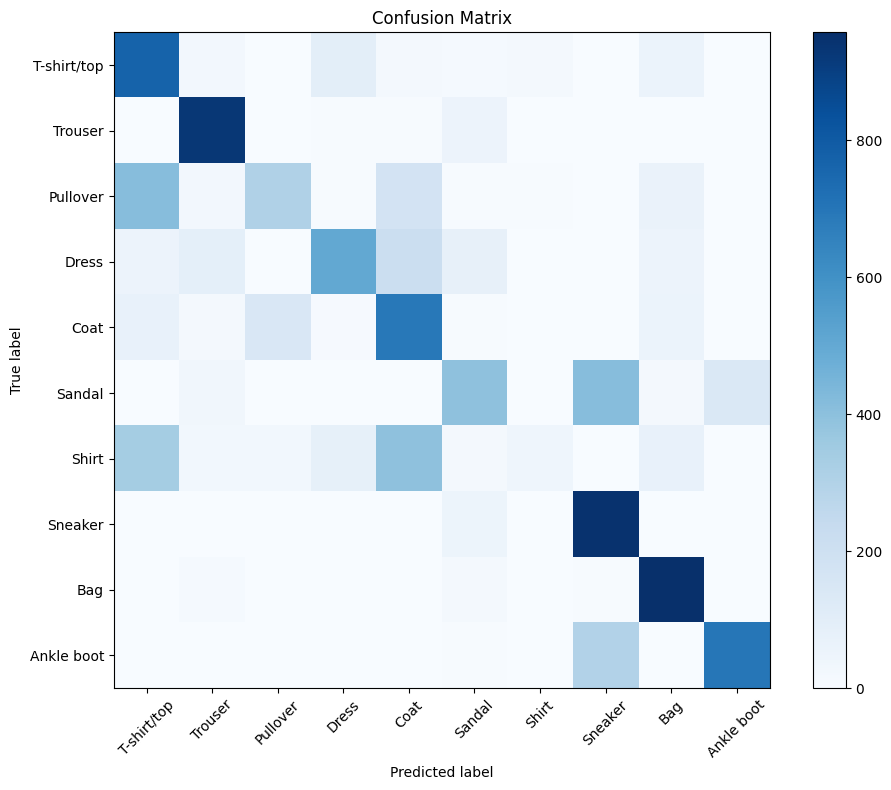

In [42]:
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# 1. Build text embeddings
text_embeddings = get_text_embeddings(CLASS_NAMES)
print(f"Text embeddings shape: {text_embeddings.shape}") 

y_true, y_pred = [], []

# 2. Loop through each batch of images
for pixel_values, labels in test_loader:
    # Get image embeddings for the batch
    image_embeddings = get_image_embeddings(pixel_values)
    
    # Compute cosine similarity between image and text embeddings
    similarity = get_cosine_similarity(image_embeddings, text_embeddings)
    
    # Get predicted class indices
    batch_preds = get_predictions(similarity)
    
    # Save true labels and predictions to lists
    y_true.extend(labels.numpy())      # Convert tensor to numpy
    y_pred.extend(batch_preds)         # Already numpy from get_predictions

# 3. Report Accuracy
print(f"Zero-Shot Accuracy: {accuracy_score(y_true, y_pred):.4f}")

# 4. Report Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_true, y_pred, CLASS_NAMES)

Reflection: Consider the results. How does the performance of this zero-shot baseline compare to the CNN you trained in Assignment 1? What are the strengths and weaknesses of this approach?
ANSWER:
without any training, it got it right 62% of the time.  With training, CNN got up to 90% (with work) and it was trained on the data-set...this wasn't trained at all yet.  it is strong telling the diffeernce between a bag verus trouser...but not similar clothing types.so it can classify never before seen by changing the text prompts...without training costs.  

## Improving Zero-Shot Classification with Prompt Engineering

In the previous section, we directly used the class names as text prompts for zero-shot classification. However, we can often improve performance by crafting more descriptive prompts that better capture the visual characteristics of each class. For example, instead of just "T-shirt/top", we could use "a photo of a T-shirt" or "a photo of a top". This additional context can help the model make more accurate predictions.

In this section, we will experiment with more detailed prompts for each class to see if we can improve the zero-shot classification performance. You should:

- [ ] Create a list of improved prompts for each class. For example, instead of just "T-shirt/top", you could use "a photo of a T-shirt" or "a photo of a top".
- [ ] Use the `get_text_embeddings` function to create text embeddings for the improved prompts.
- [ ] Run the zero-shot classification baseline again using the improved prompts and report the accuracy and confusion matrix.

Note: Take advantage of the confusion matrix above. If two classes are often confused, consider how you might improve the prompts to help the model distinguish them better.

The aim for this section is for you to improve the performance of the model. However, if you find that the performance does not improve significantly, you can still reflect on the process and consider how you might further refine the prompts with more effort.

Improved text embeddings shape: torch.Size([10, 512])

=== RESULTS ===
Baseline Accuracy (simple class names): 0.6240
Improved Accuracy (engineered prompts): 0.7067
Improvement: 0.0827

Confusion Matrix with Improved Prompts:


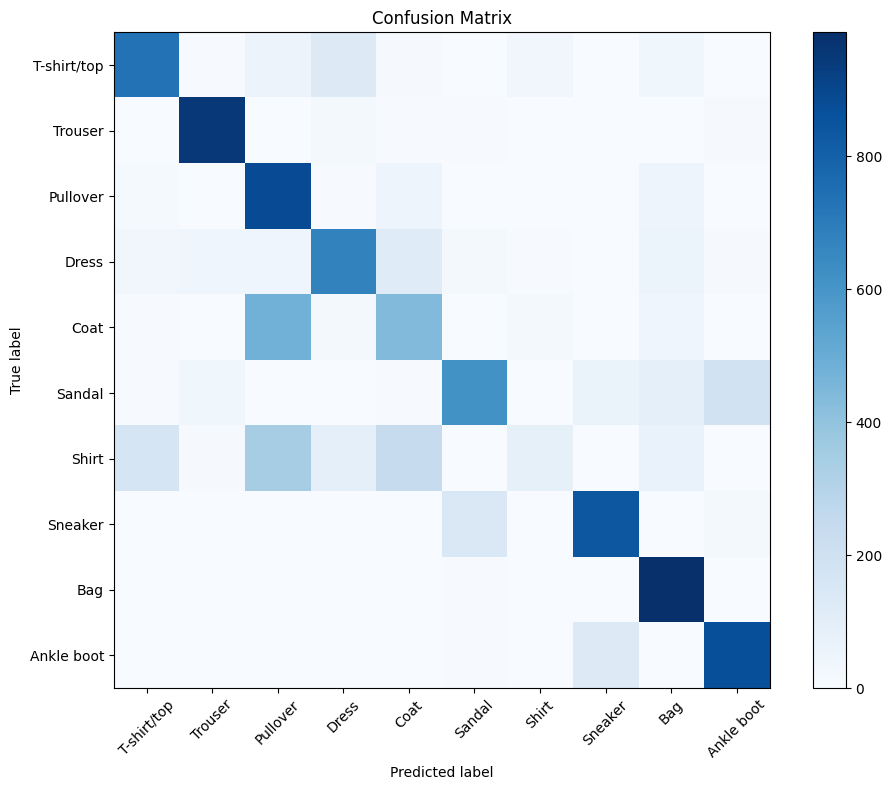


Classification Report (Improved Prompts):
              precision    recall  f1-score   support

 T-shirt/top       0.76      0.73      0.75      1000
     Trouser       0.90      0.95      0.93      1000
    Pullover       0.49      0.88      0.63      1000
       Dress       0.72      0.67      0.70      1000
        Coat       0.51      0.44      0.47      1000
      Sandal       0.77      0.62      0.69      1000
       Shirt       0.58      0.08      0.14      1000
     Sneaker       0.82      0.84      0.83      1000
         Bag       0.75      0.99      0.85      1000
  Ankle boot       0.79      0.87      0.83      1000

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.68     10000
weighted avg       0.71      0.71      0.68     10000



In [44]:
# === IMPROVED PROMPTS ===
# Strategy: Add "a photo of" (matches CLIP's training data), and synonyms to cover variations and ambiguous categories.

IMPROVED_PROMPTS = [
    "a photo of a T-shirt or top",           # T-shirt/top (class 0)
    "a photo of trousers or pants",          # Trouser (class 1)
    "a photo of a pullover sweater",         # Pullover (class 2)
    "a photo of a dress",                     # Dress (class 3)
    "a photo of a coat or jacket",            # Coat (class 4)
    "a photo of a sandal shoe",               # Sandal (class 5)
    "a photo of a shirt or blouse",           # Shirt (class 6)
    "a photo of a sneaker shoe",              # Sneaker (class 7)
    "a photo of a handbag or bag",            # Bag (class 8)
    "a photo of an ankle boot shoe"           # Ankle boot (class 9)
]

# === Get text embeddings for improved prompts ===
text_embeddings_improved = get_text_embeddings(IMPROVED_PROMPTS)
print(f"Improved text embeddings shape: {text_embeddings_improved.shape}")

# === Run classification loop with improved prompts ===
y_true_improved, y_pred_improved = [], []

for pixel_values, labels in test_loader:
    # Get image embeddings for the batch
    image_embeddings = get_image_embeddings(pixel_values)
    
    # Compute cosine similarity with improved text embeddings
    similarity = get_cosine_similarity(image_embeddings, text_embeddings_improved)
    
    # Get predicted class indices
    batch_preds = get_predictions(similarity)
    
    # Save true labels and predictions
    y_true_improved.extend(labels.numpy())
    y_pred_improved.extend(batch_preds)

# === Compare baseline vs improved accuracy ===
print("\n=== RESULTS ===")
print(f"Baseline Accuracy (simple class names): {accuracy_score(y_true, y_pred):.4f}")
print(f"Improved Accuracy (engineered prompts): {accuracy_score(y_true_improved, y_pred_improved):.4f}")
print(f"Improvement: {accuracy_score(y_true_improved, y_pred_improved) - accuracy_score(y_true, y_pred):.4f}")

# === Plot confusion matrix for improved prompts ===
print("\nConfusion Matrix with Improved Prompts:")
plot_confusion_matrix(y_true_improved, y_pred_improved, CLASS_NAMES)

# === Optional: Show which specific classes improved most ===
from sklearn.metrics import classification_report
print("\nClassification Report (Improved Prompts):")
print(classification_report(y_true_improved, y_pred_improved, target_names=CLASS_NAMES))

Reflection: How did your detailed prompts affect the zero-shot classification performance? Did you see a significant improvement compared to the baseline? What insights did you gain about the model's understanding of the classes? Do you think that with more effort you could further improve the performance? If so, how?

8% improvement wiht prompt engineering!  Shirt is till doing terrible...it gets confused with pullover and coats whiich makes sense.  CLIP benefits from more descriptive, natural language prmpts. 
We could add more descriptions ot prompts. explain better the distinguishing features.

## Visualizing Image Embeddings with UMAP

To better understand how the model perceives the different classes, we can visualize the image embeddings using UMAP (Uniform Manifold Approximation and Projection). UMAP is a dimensionality reduction technique that helps us see how similar or dissimilar the embeddings are in a lower-dimensional space.

By visualizing the embeddings, we can gain insights into how well the model can distinguish certain images, even without considering the text prompts. This can help us identify clusters of similar images and see if there are any overlaps between classes.

You should:

- [ ] Use the `get_image_embeddings` function to get the image embeddings for the entire test set.
- [ ] Use UMAP to reduce the dimensionality of the image embeddings to 2D.
- [ ] Plot the 2D embeddings, coloring each point by its true class label.

You may need to install the `umap-learn` library if you haven't already. You can do this by running `pip install umap-learn`.

In [45]:
# Uncomment the following line to install UMAP if you haven't already
!pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 15.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 21.8 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [umap-learn]4 [umap-learn]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Total embeddings collected: (10000, 512)
Total labels collected: (10000,)
Fitting UMAP...


/Users/seanbrennan/deep_learning/deep_learning/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/seanbrennan/deep_learning/deep_learning/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding shape: (10000, 2)


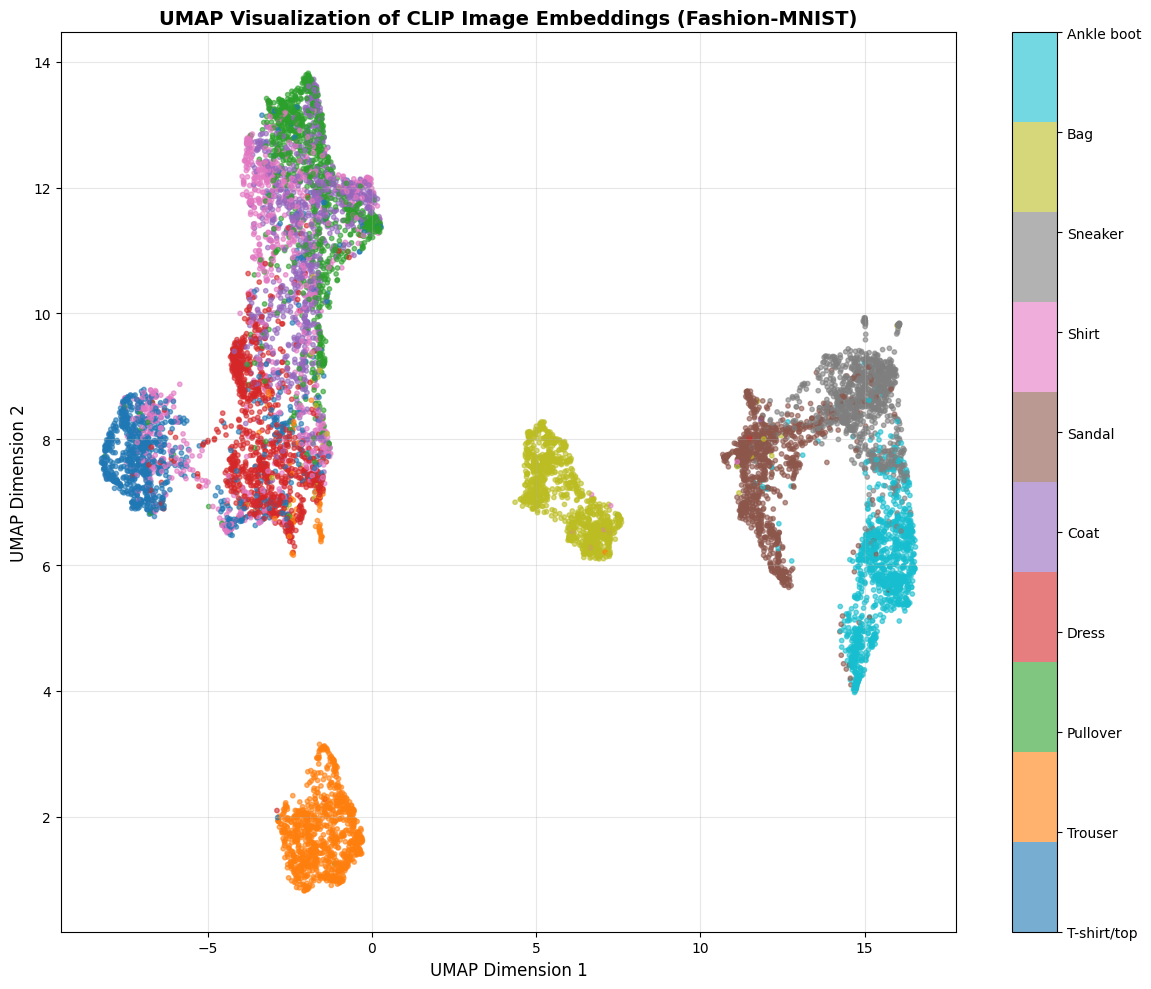

In [47]:
from umap import UMAP


# ------------------------------------------------------------
# 1. Collect image embeddings
# ------------------------------------------------------------
all_img_emb = []
all_labels  = []

for pixel_values, labels in test_loader:
    # Get image embeddings for the batch
    with torch.no_grad():
        image_embeddings = get_image_embeddings(pixel_values)
    
    # Move to CPU and convert to numpy
    all_img_emb.append(image_embeddings.cpu().numpy())
    all_labels.append(labels.numpy())

# Concatenate all batches
all_img_emb = np.vstack(all_img_emb)
all_labels = np.concatenate(all_labels)

print(f"Total embeddings collected: {all_img_emb.shape}")
print(f"Total labels collected: {all_labels.shape}")

# ------------------------------------------------------------
# 2. Fit UMAP
# ------------------------------------------------------------
print("Fitting UMAP...")
umap_model = UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
img_embeddings_2d = umap_model.fit_transform(all_img_emb)
print(f"UMAP embedding shape: {img_embeddings_2d.shape}")

# ------------------------------------------------------------
# 3. Plot coloured by ground-truth label
# ------------------------------------------------------------
plt.figure(figsize=(12, 10))

# Create a scatter plot with different colors for each class
scatter = plt.scatter(img_embeddings_2d[:, 0], img_embeddings_2d[:, 1], 
                      c=all_labels, cmap='tab10', s=10, alpha=0.6)

# Add colorbar with class names
cbar = plt.colorbar(scatter, ticks=range(len(CLASS_NAMES)))
cbar.ax.set_yticklabels(CLASS_NAMES)  # This labels the colorbar, not the y-axis

plt.title('UMAP Visualization of CLIP Image Embeddings (Fashion-MNIST)', fontsize=14, fontweight='bold')
plt.xlabel('UMAP Dimension 1', fontsize=12)
plt.ylabel('UMAP Dimension 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The UMAP embeddings allow us to see how separable or non-separable different classes are with our specific model. If two specific images are very similar, then they will be placed near each other on this graph. 

Reflection: Do you notice any challenges in distinguishing images based on this figure? Are there any types of clothing in the dataset which the model has no trouble distinguishing from the others?


The shirt class (with only 8% recall) sits right in the middle of a big cluster of upper-body clothing... t-shirts, pullovers, and coats...which is obvious for us with clothing... and obvious why it was getting misclassified!

Trousers are all alone... completely separate from everything else...not even close and the model nailed it 95% of the time.

Bags also have their own clean cluster...explains the 99% recall.

All the footwear (sandals, sneakers, ankle boots) cluster together in the same neighborhood. They overlap often, causing the confusion we saw between these classes.a brown in the middle of aqua blue will obviously be wrongly classified.

Makes perfect sense when thinking of how clothing looks like and helps to see it plotted.


## Mini-Experiment

In this section, you will conduct a mini-experiment of your choice to further explore the capabilities of zero-shot classification with transformers. This can be anything you'd like, but here are some ideas to get you started.

### A. Alternative Model

So far we have been utilizing OpenAI's CLIP model for zero-shot classification. However, there are many other vision–language models available in the `transformers` library that you can experiment with. For example, there are larger CLIP models such as [clip-vit-large-patch14](https://huggingface.co/openai/clip-vit-large-patch14), and open-source versions such as [laion/CLIP-ViT-B-32-laion2B-s34B-b79K](https://huggingface.co/laion/CLIP-ViT-B-32-laion2B-s34B-b79K). You can also search huggingface [here](https://huggingface.co/models?sort=trending&search=clip) to find other models that might be suitable for zero-shot classification.

You can try using a different model to see if it improves the zero-shot classification performance. You should:
- [ ] Load a different model and processor from the `transformers` library.
- [ ] Run the zero-shot classification baseline with the new model and report the accuracy and confusion matrix.
- [ ] Reflect on the performance of the new model compared to the original CLIP model
  - How does the new model perform compared to the original CLIP model?
  - Do you notice any differences in the types of errors made by the new model?

### B. Multiple-Description Classification

Another interesting experiment is to explore multiple-description classification. *This involves providing multiple text prompts for each class, allowing the model to choose the most relevant one. For example, instead of just "T-shirt/top", you could provide "a photo of a T-shirt", "a photo of a top", and "a photo of a shirt". This can help the model better understand the class and increases the likelihood of a correct prediction. You should:

- [ ] Create a list of multiple prompts for each class.
- [ ] Use the `get_text_embeddings` function to create text embeddings for the multiple prompts.
- [ ] Run the zero-shot classification baseline again using the multiple prompts and report the accuracy and confusion matrix.
- [ ] Consider the model to be correct if it guesses *any* of the prompts belonging to the correct class.

### C. Top-K Classification

In some classification tasks, it can be useful to consider if the right answer is among the top K (e.g. top 3) predictions. This can be particularly useful in cases where the model is uncertain or when there are multiple similar classes. You should:

- [ ] Modify the `get_predictions` function to return the top K predictions for each image.
- [ ] Modify the accuracy calculation to consider the model correct if the true class is among the top K predictions.
- [ ] Report the accuracy and confusion matrix for the top K predictions. Report at least two different values of K (e.g. K=2 and K=4).

### D. Other Ideas

You are welcome to come up with your own mini-experiment! Explain your idea in the report and implement it. Did it work as you expected? What did you learn from it?

Total prompts: 71
Prompts per class: [10, 5, 8, 7, 9, 5, 12, 5, 5, 5]
Multi-prompt embeddings shape: torch.Size([71, 512])

=== MULTI-PROMPT RESULTS ===
Baseline Accuracy (simple class names): 0.6240
Single improved prompts: 0.7067
Multi-prompt (multiple descriptions): 0.5877
Improvement over baseline: -0.0363

Confusion Matrix with Multiple Prompts:


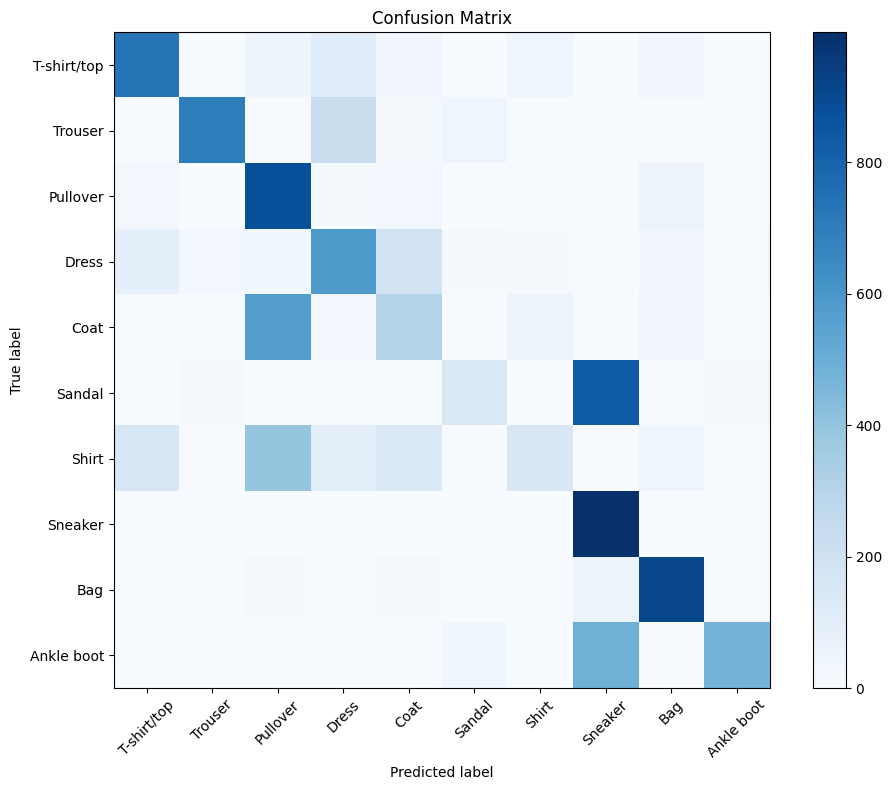


Multi-Prompt Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.72      0.73      0.72      1000
     Trouser       0.93      0.70      0.80      1000
    Pullover       0.45      0.88      0.59      1000
       Dress       0.55      0.59      0.57      1000
        Coat       0.42      0.30      0.35      1000
      Sandal       0.61      0.15      0.24      1000
       Shirt       0.55      0.15      0.24      1000
     Sneaker       0.42      1.00      0.59      1000
         Bag       0.83      0.91      0.87      1000
  Ankle boot       0.97      0.47      0.63      1000

    accuracy                           0.59     10000
   macro avg       0.64      0.59      0.56     10000
weighted avg       0.64      0.59      0.56     10000



In [49]:
# Multiple prompts per class... asked Deepseek for expanded list for the ones that struggled
MULTI_PROMPTS = {
    "T-shirt/top": [
        "a photo of a t-shirt",
        "a photo of a top",
        "a photo of a short sleeve t-shirt",
        "a photo of a casual t-shirt with short sleeves",
        "a photo of a crew neck t-shirt",
        "a photo of a cotton t-shirt",
        "a photo of a t-shirt with no buttons",
        "a photo of a casual top without buttons",
        "a photo of a soft fabric t-shirt",
        "a photo of a round neck t-shirt"
    ],
    
    "Shirt": [
        "a photo of a shirt",
        "a photo of a dress shirt",
        "a photo of a button-up shirt",
        "a photo of a formal shirt with buttons",
        "a photo of a collared shirt",
        "a photo of a long sleeve button-down shirt",
        "a photo of an oxford shirt",
        "a photo of a business shirt with buttons down the front",
        "a photo of a shirt with a collar and buttons",
        "a photo of a pressed formal shirt",
        "a photo of a men's dress shirt",
        "a photo of a button-up blouse"
    ],
    
    "Pullover": [
        "a photo of a pullover",
        "a photo of a sweater",
        "a photo of a knitted pullover sweater",
        "a photo of a wool sweater",
        "a photo of a long sleeve pullover",
        "a photo of a cozy winter sweater",
        "a photo of a pullover with no buttons",
        "a photo of a knitted garment you pull over your head"
    ],
    
    "Coat": [
        "a photo of a coat",
        "a photo of a jacket",
        "a photo of a long winter coat",
        "a photo of a heavy outerwear jacket",
        "a photo of a coat that opens in the front",
        "a photo of a wool coat",
        "a photo of a trench coat",
        "a photo of a warm coat with buttons or zipper",
        "a photo of outerwear worn over other clothes"
    ],
    
    "Dress": [
        "a photo of a dress",
        "a photo of a women's dress",
        "a photo of a one-piece garment for women",
        "a photo of a formal dress",
        "a photo of a casual dress",
        "a photo of a dress that goes from shoulders to legs",
        "a photo of a single piece of clothing covering torso and legs"
    ],
    
    "Trouser": [
        "a photo of trousers",
        "a photo of pants",
        "a photo of dress pants",
        "a photo of long pants",
        "a photo of formal trousers"
    ],
    
    "Sandal": [
        "a photo of sandals",
        "a photo of open-toe shoes",
        "a photo of summer sandals",
        "a photo of shoes with straps",
        "a photo of flat sandals"
    ],
    
    "Sneaker": [
        "a photo of sneakers",
        "a photo of athletic shoes",
        "a photo of running shoes",
        "a photo of sports shoes",
        "a photo of casual sneakers"
    ],
    
    "Bag": [
        "a photo of a handbag",
        "a photo of a purse",
        "a photo of a shoulder bag",
        "a photo of a tote bag",
        "a photo of a leather bag"
    ],
    
    "Ankle boot": [
        "a photo of ankle boots",
        "a photo of short boots",
        "a photo of winter boots",
        "a photo of lace-up boots",
        "a photo of leather ankle boots"
    ]
}

# === FLATTEN THE PROMPTS AND TRACK CLASS MAPPING ===
all_prompts = []
prompt_to_class = []

for class_idx, class_name in enumerate(CLASS_NAMES):
    for prompt in MULTI_PROMPTS[class_name]:
        all_prompts.append(prompt)
        prompt_to_class.append(class_idx)

print(f"Total prompts: {len(all_prompts)}")
print(f"Prompts per class: {[len(MULTI_PROMPTS[c]) for c in CLASS_NAMES]}")

# === Get text embeddings for all prompts ===
text_embeddings_multi = get_text_embeddings(all_prompts)
print(f"Multi-prompt embeddings shape: {text_embeddings_multi.shape}")

# === Run classification with multiple prompts ===
y_true_multi, y_pred_multi = [], []

for pixel_values, labels in test_loader:
    # Get image embeddings for the batch
    image_embeddings = get_image_embeddings(pixel_values)
    
    # Compute cosine similarity with all prompts
    similarity = get_cosine_similarity(image_embeddings, text_embeddings_multi)
    
    # For each image, take the maximum similarity across prompts for each class
    # similarity shape: (batch_size, total_prompts)
    batch_size = similarity.shape[0]
    num_classes = len(CLASS_NAMES)
    
    # Create array to store max similarity per class
    class_similarities = np.zeros((batch_size, num_classes))
    
    # For each prompt, add its similarity to the corresponding class (taking max)
    for prompt_idx, class_idx in enumerate(prompt_to_class):
        class_similarities[:, class_idx] = np.maximum(
            class_similarities[:, class_idx], 
            similarity[:, prompt_idx]
        )
    
    # Get predictions (class with highest similarity)
    batch_preds = np.argmax(class_similarities, axis=1)
    
    # Save true labels and predictions
    y_true_multi.extend(labels.numpy())
    y_pred_multi.extend(batch_preds)

# === Compare results ===
print("\n=== MULTI-PROMPT RESULTS ===")
print(f"Baseline Accuracy (simple class names): {accuracy_score(y_true, y_pred):.4f}")
print(f"Single improved prompts: {accuracy_score(y_true_improved, y_pred_improved):.4f}")
print(f"Multi-prompt (multiple descriptions): {accuracy_score(y_true_multi, y_pred_multi):.4f}")
print(f"Improvement over baseline: {accuracy_score(y_true_multi, y_pred_multi) - accuracy_score(y_true, y_pred):.4f}")

# === Plot confusion matrix for multi-prompt ===
print("\nConfusion Matrix with Multiple Prompts:")
plot_confusion_matrix(y_true_multi, y_pred_multi, CLASS_NAMES)

# === Classification report ===
from sklearn.metrics import classification_report
print("\nMulti-Prompt Classification Report:")
print(classification_report(y_true_multi, y_pred_multi, target_names=CLASS_NAMES))

Total prompts: 71
Prompts per class: [10, 5, 8, 7, 9, 5, 12, 5, 5, 5]
Multi-prompt embeddings shape: torch.Size([71, 512])

=== MULTI-PROMPT RESULTS (AVERAGING) ===
Baseline Accuracy (simple class names): 0.6240
Single improved prompts: 0.7067
Multi-prompt (averaged): 0.6439
Improvement over baseline: 0.0199

Confusion Matrix with Multiple Prompts (Averaged):


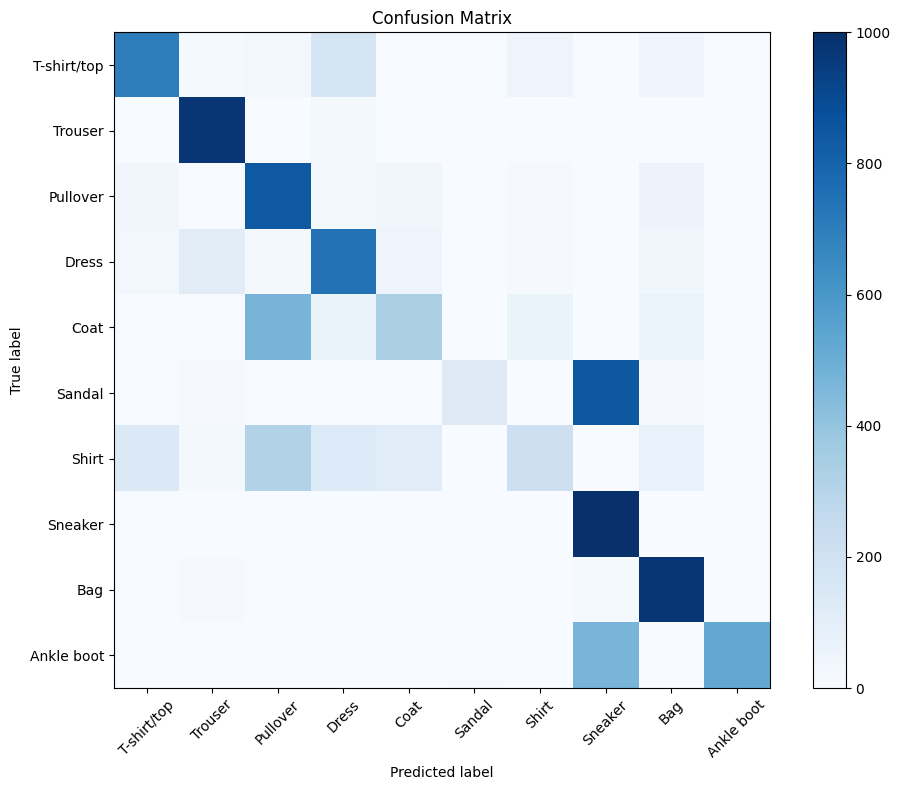


Multi-Prompt Classification Report (Averaged):
              precision    recall  f1-score   support

 T-shirt/top       0.77      0.70      0.74      1000
     Trouser       0.85      0.97      0.91      1000
    Pullover       0.50      0.84      0.63      1000
       Dress       0.65      0.74      0.69      1000
        Coat       0.62      0.33      0.43      1000
      Sandal       0.92      0.13      0.22      1000
       Shirt       0.62      0.21      0.32      1000
     Sneaker       0.43      1.00      0.60      1000
         Bag       0.78      0.97      0.87      1000
  Ankle boot       0.99      0.53      0.69      1000

    accuracy                           0.64     10000
   macro avg       0.71      0.64      0.61     10000
weighted avg       0.71      0.64      0.61     10000



In [51]:
# Multiple prompts per class... equal list per class
MULTI_PROMPTS = {
    "T-shirt/top": [
        "a photo of a t-shirt",
        "a photo of a top",
        "a photo of a short sleeve t-shirt",
        "a photo of a casual t-shirt with short sleeves",
        "a photo of a crew neck t-shirt",
        "a photo of a cotton t-shirt",
        "a photo of a t-shirt with no buttons",
        "a photo of a casual top without buttons",
        "a photo of a soft fabric t-shirt",
        "a photo of a round neck t-shirt"
    ],
    
    "Shirt": [
        "a photo of a shirt",
        "a photo of a dress shirt",
        "a photo of a button-up shirt",
        "a photo of a formal shirt with buttons",
        "a photo of a collared shirt",
        "a photo of a long sleeve button-down shirt",
        "a photo of an oxford shirt",
        "a photo of a business shirt with buttons down the front",
        "a photo of a shirt with a collar and buttons",
        "a photo of a pressed formal shirt",
        "a photo of a men's dress shirt",
        "a photo of a button-up blouse"
    ],
    
    "Pullover": [
        "a photo of a pullover",
        "a photo of a sweater",
        "a photo of a knitted pullover sweater",
        "a photo of a wool sweater",
        "a photo of a long sleeve pullover",
        "a photo of a cozy winter sweater",
        "a photo of a pullover with no buttons",
        "a photo of a knitted garment you pull over your head"
    ],
    
    "Coat": [
        "a photo of a coat",
        "a photo of a jacket",
        "a photo of a long winter coat",
        "a photo of a heavy outerwear jacket",
        "a photo of a coat that opens in the front",
        "a photo of a wool coat",
        "a photo of a trench coat",
        "a photo of a warm coat with buttons or zipper",
        "a photo of outerwear worn over other clothes"
    ],
    
    "Dress": [
        "a photo of a dress",
        "a photo of a women's dress",
        "a photo of a one-piece garment for women",
        "a photo of a formal dress",
        "a photo of a casual dress",
        "a photo of a dress that goes from shoulders to legs",
        "a photo of a single piece of clothing covering torso and legs"
    ],
    
    "Trouser": [
        "a photo of trousers",
        "a photo of pants",
        "a photo of dress pants",
        "a photo of long pants",
        "a photo of formal trousers"
    ],
    
    "Sandal": [
        "a photo of sandals",
        "a photo of open-toe shoes",
        "a photo of summer sandals",
        "a photo of shoes with straps",
        "a photo of flat sandals"
    ],
    
    "Sneaker": [
        "a photo of sneakers",
        "a photo of athletic shoes",
        "a photo of running shoes",
        "a photo of sports shoes",
        "a photo of casual sneakers"
    ],
    
    "Bag": [
        "a photo of a handbag",
        "a photo of a purse",
        "a photo of a shoulder bag",
        "a photo of a tote bag",
        "a photo of a leather bag"
    ],
    
    "Ankle boot": [
        "a photo of ankle boots",
        "a photo of short boots",
        "a photo of winter boots",
        "a photo of lace-up boots",
        "a photo of leather ankle boots"
    ]
}

# === FLATTEN THE PROMPTS AND TRACK CLASS MAPPING ===
all_prompts = []
prompt_to_class = []

for class_idx, class_name in enumerate(CLASS_NAMES):
    for prompt in MULTI_PROMPTS[class_name]:
        all_prompts.append(prompt)
        prompt_to_class.append(class_idx)

print(f"Total prompts: {len(all_prompts)}")
print(f"Prompts per class: {[len(MULTI_PROMPTS[c]) for c in CLASS_NAMES]}")

# === Get text embeddings for all prompts ===
text_embeddings_multi = get_text_embeddings(all_prompts)
print(f"Multi-prompt embeddings shape: {text_embeddings_multi.shape}")

# === Run classification with multiple prompts (using AVERAGE) ===
y_true_multi, y_pred_multi = [], []

for pixel_values, labels in test_loader:
    # Get image embeddings for the batch
    image_embeddings = get_image_embeddings(pixel_values)
    
    # Compute cosine similarity with all prompts
    similarity = get_cosine_similarity(image_embeddings, text_embeddings_multi)
    
    # For each image, take the AVERAGE similarity across prompts for each class
    # similarity shape: (batch_size, total_prompts)
    batch_size = similarity.shape[0]
    num_classes = len(CLASS_NAMES)
    
    # Create array to store sum of similarities per class
    class_similarities_sum = np.zeros((batch_size, num_classes))
    class_counts = np.zeros(num_classes)
    
    # Sum similarities for each class
    for prompt_idx, class_idx in enumerate(prompt_to_class):
        class_similarities_sum[:, class_idx] += similarity[:, prompt_idx]
        class_counts[class_idx] += 1
    
    # Divide by number of prompts per class to get AVERAGE
    class_similarities = class_similarities_sum / class_counts
    
    # Get predictions (class with highest average similarity)
    batch_preds = np.argmax(class_similarities, axis=1)
    
    # Save true labels and predictions
    y_true_multi.extend(labels.numpy())
    y_pred_multi.extend(batch_preds)

# === Compare results ===
print("\n=== MULTI-PROMPT RESULTS (AVERAGING) ===")
print(f"Baseline Accuracy (simple class names): {accuracy_score(y_true, y_pred):.4f}")
print(f"Single improved prompts: {accuracy_score(y_true_improved, y_pred_improved):.4f}")
print(f"Multi-prompt (averaged): {accuracy_score(y_true_multi, y_pred_multi):.4f}")
print(f"Improvement over baseline: {accuracy_score(y_true_multi, y_pred_multi) - accuracy_score(y_true, y_pred):.4f}")

# === Plot confusion matrix for multi-prompt ===
print("\nConfusion Matrix with Multiple Prompts (Averaged):")
plot_confusion_matrix(y_true_multi, y_pred_multi, CLASS_NAMES)

# === Classification report ===
from sklearn.metrics import classification_report
print("\nMulti-Prompt Classification Report (Averaged):")
print(classification_report(y_true_multi, y_pred_multi, target_names=CLASS_NAMES))


=== APPROACH 1: Averaging embeddings per class ===
Averaged embeddings shape: torch.Size([10, 512])
Averaged embeddings accuracy: 0.6439

=== APPROACH 2: Reduced prompts (2-3 most distinctive per class) ===
Reduced prompts embeddings shape: torch.Size([20, 512])
Reduced prompts accuracy: 0.6343

FINAL COMPARISON
Baseline (simple class names):          0.6240
Single improved prompts:                0.7067
Multi-prompt (max, all prompts):        0.6439
Multi-prompt (averaged embeddings):      0.6439
Multi-prompt (reduced, 2-3 prompts):    0.6343

Best result: Single improved prompts approach


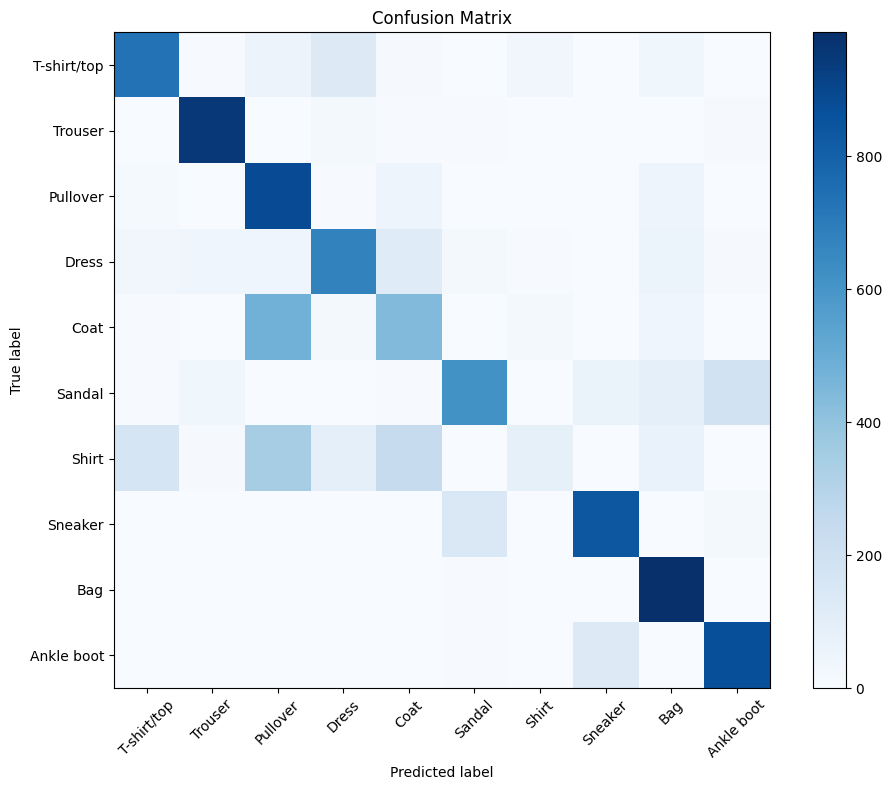

              precision    recall  f1-score   support

 T-shirt/top       0.76      0.73      0.75      1000
     Trouser       0.90      0.95      0.93      1000
    Pullover       0.49      0.88      0.63      1000
       Dress       0.72      0.67      0.70      1000
        Coat       0.51      0.44      0.47      1000
      Sandal       0.77      0.62      0.69      1000
       Shirt       0.58      0.08      0.14      1000
     Sneaker       0.82      0.84      0.83      1000
         Bag       0.75      0.99      0.85      1000
  Ankle boot       0.79      0.87      0.83      1000

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.68     10000
weighted avg       0.71      0.71      0.68     10000



In [ ]:
# Multiple prompts per class... asked Deepseek for expanded list for the ones that struggled
MULTI_PROMPTS = {
    "T-shirt/top": [
        "a photo of a t-shirt",
        "a photo of a top",
        "a photo of a short sleeve t-shirt",
        "a photo of a casual t-shirt with short sleeves",
        "a photo of a crew neck t-shirt",
        "a photo of a cotton t-shirt",
        "a photo of a t-shirt with no buttons",
        "a photo of a casual top without buttons",
        "a photo of a soft fabric t-shirt",
        "a photo of a round neck t-shirt"
    ],
    
    "Shirt": [
        "a photo of a shirt",
        "a photo of a dress shirt",
        "a photo of a button-up shirt",
        "a photo of a formal shirt with buttons",
        "a photo of a collared shirt",
        "a photo of a long sleeve button-down shirt",
        "a photo of an oxford shirt",
        "a photo of a business shirt with buttons down the front",
        "a photo of a shirt with a collar and buttons",
        "a photo of a pressed formal shirt",
        "a photo of a men's dress shirt",
        "a photo of a button-up blouse"
    ],
    
    "Pullover": [
        "a photo of a pullover",
        "a photo of a sweater",
        "a photo of a knitted pullover sweater",
        "a photo of a wool sweater",
        "a photo of a long sleeve pullover",
        "a photo of a cozy winter sweater",
        "a photo of a pullover with no buttons",
        "a photo of a knitted garment you pull over your head"
    ],
    
    "Coat": [
        "a photo of a coat",
        "a photo of a jacket",
        "a photo of a long winter coat",
        "a photo of a heavy outerwear jacket",
        "a photo of a coat that opens in the front",
        "a photo of a wool coat",
        "a photo of a trench coat",
        "a photo of a warm coat with buttons or zipper",
        "a photo of outerwear worn over other clothes"
    ],
    
    "Dress": [
        "a photo of a dress",
        "a photo of a women's dress",
        "a photo of a one-piece garment for women",
        "a photo of a formal dress",
        "a photo of a casual dress",
        "a photo of a dress that goes from shoulders to legs",
        "a photo of a single piece of clothing covering torso and legs"
    ],
    
    "Trouser": [
        "a photo of trousers",
        "a photo of pants",
        "a photo of dress pants",
        "a photo of long pants",
        "a photo of formal trousers"
    ],
    
    "Sandal": [
        "a photo of sandals",
        "a photo of open-toe shoes",
        "a photo of summer sandals",
        "a photo of shoes with straps",
        "a photo of flat sandals"
    ],
    
    "Sneaker": [
        "a photo of sneakers",
        "a photo of athletic shoes",
        "a photo of running shoes",
        "a photo of sports shoes",
        "a photo of casual sneakers"
    ],
    
    "Bag": [
        "a photo of a handbag",
        "a photo of a purse",
        "a photo of a shoulder bag",
        "a photo of a tote bag",
        "a photo of a leather bag"
    ],
    
    "Ankle boot": [
        "a photo of ankle boots",
        "a photo of short boots",
        "a photo of winter boots",
        "a photo of lace-up boots",
        "a photo of leather ankle boots"
    ]
}

# === APPROACH 1: AVERAGE EMBEDDINGS PER CLASS (Recommended) ===
print("\n=== APPROACH 1: Averaging embeddings per class ===")

# Get embeddings for each class by averaging their prompts
class_avg_embeddings = []

for class_name in CLASS_NAMES:
    prompts = MULTI_PROMPTS[class_name]
    # Get embeddings for all prompts in this class
    prompt_embeds = get_text_embeddings(prompts)  # Shape: [num_prompts, 512]
    # Average them
    class_avg = prompt_embeds.mean(dim=0, keepdim=True)  # Shape: [1, 512]
    class_avg_embeddings.append(class_avg)

# Stack into single tensor: [10, 512]
text_embeddings_avg = torch.vstack(class_avg_embeddings)
print(f"Averaged embeddings shape: {text_embeddings_avg.shape}")

# Run classification with averaged embeddings
y_true_avg, y_pred_avg = [], []

for pixel_values, labels in test_loader:
    image_embeddings = get_image_embeddings(pixel_values)
    similarity = get_cosine_similarity(image_embeddings, text_embeddings_avg)
    batch_preds = get_predictions(similarity)
    y_true_avg.extend(labels.numpy())
    y_pred_avg.extend(batch_preds)

print(f"Averaged embeddings accuracy: {accuracy_score(y_true_avg, y_pred_avg):.4f}")

# === APPROACH 2: REDUCED PROMPTS (2-3 most distinctive per class) ===
print("\n=== APPROACH 2: Reduced prompts (2-3 most distinctive per class) ===")

REDUCED_PROMPTS = {
    "T-shirt/top": [
        "a photo of a casual t-shirt with short sleeves",
        "a photo of a t-shirt with no buttons"
    ],
    
    "Shirt": [
        "a photo of a button-up shirt with a collar",
        "a photo of a formal dress shirt"
    ],
    
    "Pullover": [
        "a photo of a knitted pullover sweater",
        "a photo of a pullover with no buttons"
    ],
    
    "Coat": [
        "a photo of a heavy winter coat",
        "a photo of outerwear worn over other clothes"
    ],
    
    "Dress": [
        "a photo of a one-piece dress",
        "a photo of a formal dress"
    ],
    
    "Trouser": [
        "a photo of trousers",
        "a photo of dress pants"
    ],
    
    "Sandal": [
        "a photo of open-toe sandals",
        "a photo of summer sandals with straps"
    ],
    
    "Sneaker": [
        "a photo of athletic sneakers",
        "a photo of running shoes"
    ],
    
    "Bag": [
        "a photo of a handbag",
        "a photo of a shoulder bag"
    ],
    
    "Ankle boot": [
        "a photo of ankle boots",
        "a photo of short lace-up boots"
    ]
}

# Flatten reduced prompts
reduced_prompts = []
reduced_prompt_to_class = []

for class_idx, class_name in enumerate(CLASS_NAMES):
    for prompt in REDUCED_PROMPTS[class_name]:
        reduced_prompts.append(prompt)
        reduced_prompt_to_class.append(class_idx)

# Get embeddings
text_embeddings_reduced = get_text_embeddings(reduced_prompts)
print(f"Reduced prompts embeddings shape: {text_embeddings_reduced.shape}")

# Run classification with reduced prompts (using max)
y_true_reduced, y_pred_reduced = [], []

for pixel_values, labels in test_loader:
    image_embeddings = get_image_embeddings(pixel_values)
    similarity = get_cosine_similarity(image_embeddings, text_embeddings_reduced)
    
    # Take max per class
    batch_size = similarity.shape[0]
    num_classes = len(CLASS_NAMES)
    class_similarities = np.zeros((batch_size, num_classes))
    
    for prompt_idx, class_idx in enumerate(reduced_prompt_to_class):
        class_similarities[:, class_idx] = np.maximum(
            class_similarities[:, class_idx], 
            similarity[:, prompt_idx]
        )
    
    batch_preds = np.argmax(class_similarities, axis=1)
    y_true_reduced.extend(labels.numpy())
    y_pred_reduced.extend(batch_preds)

print(f"Reduced prompts accuracy: {accuracy_score(y_true_reduced, y_pred_reduced):.4f}")

# === COMPARE ALL APPROACHES ===
print("\n" + "="*50)
print("COMPARISON")
print("="*50)
print(f"Baseline (simple class names):          {accuracy_score(y_true, y_pred):.4f}")
print(f"Single improved prompts:                {accuracy_score(y_true_improved, y_pred_improved):.4f}")
print(f"Multi-prompt (max, all prompts):        {accuracy_score(y_true_multi, y_pred_multi):.4f}")
print(f"Multi-prompt (averaged embeddings):      {accuracy_score(y_true_avg, y_pred_avg):.4f}")
print(f"Multi-prompt (reduced, 2-3 prompts):    {accuracy_score(y_true_reduced, y_pred_reduced):.4f}")

# === PLOT BEST APPROACH ===
best_accuracy = max(
    accuracy_score(y_true, y_pred),
    accuracy_score(y_true_improved, y_pred_improved),
    accuracy_score(y_true_multi, y_pred_multi),
    accuracy_score(y_true_avg, y_pred_avg),
    accuracy_score(y_true_reduced, y_pred_reduced)
)

if best_accuracy == accuracy_score(y_true_reduced, y_pred_reduced):
    print("\nBest result: Reduced prompts approach")
    plot_confusion_matrix(y_true_reduced, y_pred_reduced, CLASS_NAMES)
    print(classification_report(y_true_reduced, y_pred_reduced, target_names=CLASS_NAMES))
elif best_accuracy == accuracy_score(y_true_avg, y_pred_avg):
    print("\nBest result: Averaged embeddings approach")
    plot_confusion_matrix(y_true_avg, y_pred_avg, CLASS_NAMES)
    print(classification_report(y_true_avg, y_pred_avg, target_names=CLASS_NAMES))
elif best_accuracy == accuracy_score(y_true_improved, y_pred_improved):
    print("\nBest result: Single improved prompts approach")
    plot_confusion_matrix(y_true_improved, y_pred_improved, CLASS_NAMES)
    print(classification_report(y_true_improved, y_pred_improved, target_names=CLASS_NAMES))


=== APPROACH 4: Hybrid prompts (best single + distinguishing features) ===
Total hybrid prompts: 20
Prompts per class: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
Hybrid prompts embeddings shape: torch.Size([20, 512])
Hybrid prompts accuracy: 0.6101

FINAL COMPARISON - ALL APPROACHES
1. Baseline (simple class names):          0.6240
2. Single improved prompts:                0.7067
3. Multi-prompt (max, all prompts):        0.6439
4. Multi-prompt (averaged embeddings):      0.6439
5. Multi-prompt (reduced, 2-3 prompts):    0.6343
6. HYBRID (best single + distinguishing):  0.6101

🏆 BEST APPROACH: Single improved with 0.7067 accuracy

CLASSIFICATION REPORT - SINGLE IMPROVED PROMPTS (BEST APPROACH)
              precision    recall  f1-score   support

 T-shirt/top       0.76      0.73      0.75      1000
     Trouser       0.90      0.95      0.93      1000
    Pullover       0.49      0.88      0.63      1000
       Dress       0.72      0.67      0.70      1000
        Coat       0.51      0.44  

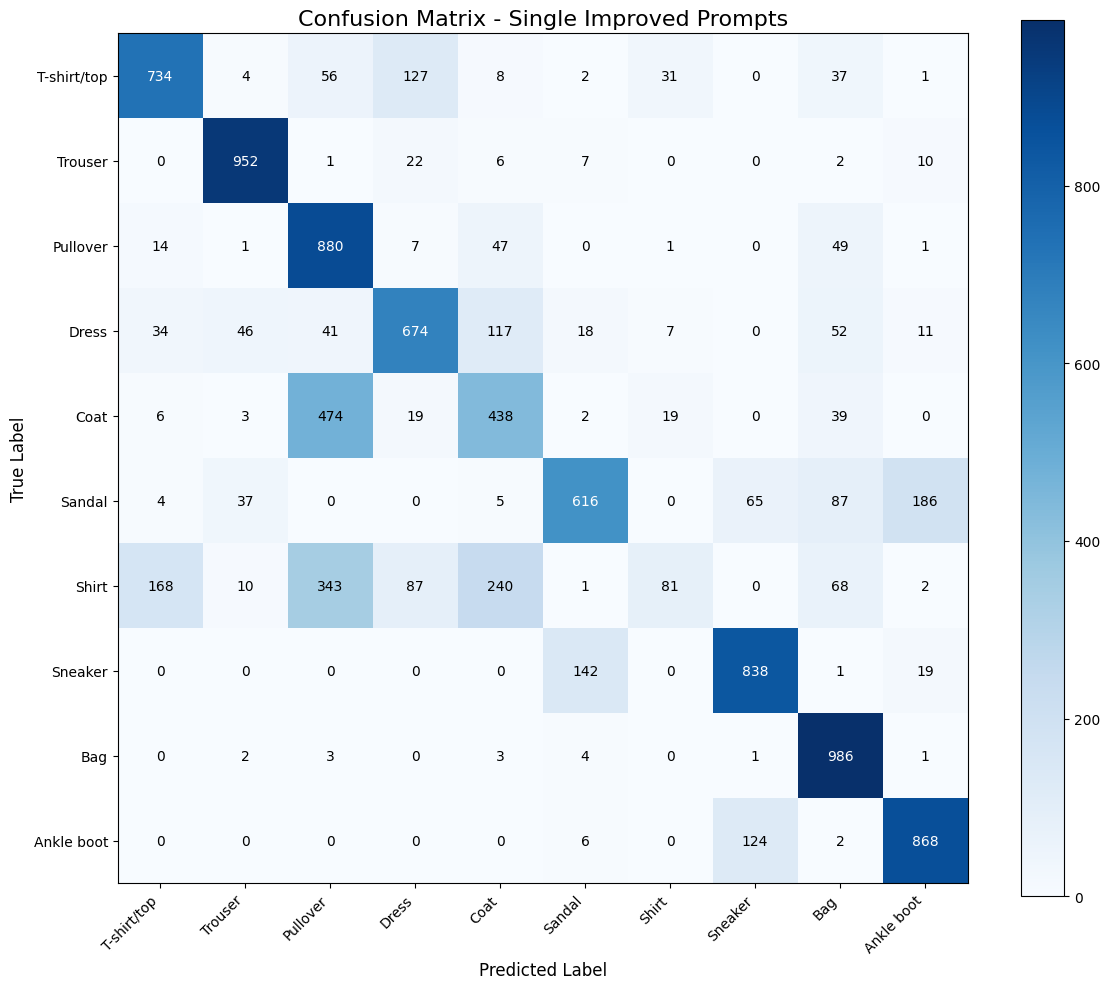

In [56]:
# === APPROACH 4: Hybrid approach - best single prompt + distinguishing features ===
print("\n=== APPROACH 4: Hybrid prompts (best single + distinguishing features) ===")

HYBRID_PROMPTS = {
    "T-shirt/top": [
        "a photo of a casual t-shirt with short sleeves",
        "a photo of a soft cotton t-shirt with no buttons"
    ],
    
    "Shirt": [
        "a photo of a button-up shirt with a collar",
        "a photo of a formal dress shirt with buttons"
    ],
    
    "Pullover": [
        "a photo of a knitted pullover sweater",
        "a photo of a wool sweater with long sleeves"
    ],
    
    "Coat": [
        "a photo of a heavy winter coat",
        "a photo of a long trench coat that opens in front"
    ],
    
    "Dress": [
        "a photo of a one-piece dress",
        "a photo of a formal evening dress"
    ],
    
    "Trouser": [
        "a photo of trousers",
        "a photo of formal dress pants"
    ],
    
    "Sandal": [
        "a photo of open-toe sandals with straps",
        "a photo of flat summer sandals"
    ],
    
    "Sneaker": [
        "a photo of athletic sneakers",
        "a photo of white running shoes"
    ],
    
    "Bag": [
        "a photo of a handbag",
        "a photo of a leather shoulder bag"
    ],
    
    "Ankle boot": [
        "a photo of ankle boots",
        "a photo of short lace-up boots"
    ]
}

# Flatten hybrid prompts
hybrid_prompts = []
hybrid_prompt_to_class = []

for class_idx, class_name in enumerate(CLASS_NAMES):
    for prompt in HYBRID_PROMPTS[class_name]:
        hybrid_prompts.append(prompt)
        hybrid_prompt_to_class.append(class_idx)

print(f"Total hybrid prompts: {len(hybrid_prompts)}")
print(f"Prompts per class: {[len(HYBRID_PROMPTS[c]) for c in CLASS_NAMES]}")

# Get embeddings
text_embeddings_hybrid = get_text_embeddings(hybrid_prompts)
print(f"Hybrid prompts embeddings shape: {text_embeddings_hybrid.shape}")

# Run classification with hybrid prompts (using AVERAGE)
y_true_hybrid, y_pred_hybrid = [], []

for pixel_values, labels in test_loader:
    image_embeddings = get_image_embeddings(pixel_values)
    similarity = get_cosine_similarity(image_embeddings, text_embeddings_hybrid)
    
    # Average per class
    batch_size = similarity.shape[0]
    num_classes = len(CLASS_NAMES)
    class_similarities_sum = np.zeros((batch_size, num_classes))
    class_counts = np.zeros(num_classes)
    
    for prompt_idx, class_idx in enumerate(hybrid_prompt_to_class):
        class_similarities_sum[:, class_idx] += similarity[:, prompt_idx]
        class_counts[class_idx] += 1
    
    class_similarities = class_similarities_sum / class_counts
    batch_preds = np.argmax(class_similarities, axis=1)
    
    y_true_hybrid.extend(labels.numpy())
    y_pred_hybrid.extend(batch_preds)

hybrid_accuracy = accuracy_score(y_true_hybrid, y_pred_hybrid)
print(f"Hybrid prompts accuracy: {hybrid_accuracy:.4f}")

# === COMPARISON TABLE ===
print("\n" + "="*60)
print("FINAL COMPARISON - ALL APPROACHES")
print("="*60)
print(f"1. Baseline (simple class names):          {accuracy_score(y_true, y_pred):.4f}")
print(f"2. Single improved prompts:                {accuracy_score(y_true_improved, y_pred_improved):.4f}")
print(f"3. Multi-prompt (max, all prompts):        {accuracy_score(y_true_multi, y_pred_multi):.4f}")
print(f"4. Multi-prompt (averaged embeddings):      {accuracy_score(y_true_avg, y_pred_avg):.4f}")
print(f"5. Multi-prompt (reduced, 2-3 prompts):    {accuracy_score(y_true_reduced, y_pred_reduced):.4f}")
print(f"6. HYBRID (best single + distinguishing):  {hybrid_accuracy:.4f}")

# Identify best approach
accuracies = [
    accuracy_score(y_true, y_pred),
    accuracy_score(y_true_improved, y_pred_improved),
    accuracy_score(y_true_multi, y_pred_multi),
    accuracy_score(y_true_avg, y_pred_avg),
    accuracy_score(y_true_reduced, y_pred_reduced),
    hybrid_accuracy
]

approach_names = [
    "Baseline",
    "Single improved", 
    "Multi-max",
    "Multi-avg",
    "Reduced",
    "Hybrid"
]

best_idx = np.argmax(accuracies)
best_acc = accuracies[best_idx]
best_name = approach_names[best_idx]

print(f"\n🏆 BEST APPROACH: {best_name} with {best_acc:.4f} accuracy")

# ===== DIRECT OUTPUT FOR SINGLE IMPROVED PROMPTS (since we know it's the best) =====
print("\n" + "="*60)
print("CLASSIFICATION REPORT - SINGLE IMPROVED PROMPTS (BEST APPROACH)")
print("="*60)

from sklearn.metrics import classification_report
print(classification_report(y_true_improved, y_pred_improved, target_names=CLASS_NAMES))

# Plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title, fontsize=16)
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha='right')
    plt.yticks(tick_marks, class_names)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    
    # Add text annotations
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_true_improved, y_pred_improved, CLASS_NAMES, "Confusion Matrix - Single Improved Prompts")

### Short Report

In this section, you will write a short report summarizing your findings from the mini-experiment. The report should include the following sections:

- **Introduction**: Briefly describe the mini-experiment you conducted and its objectives.
- **Methodology**: Explain the steps you took to conduct the experiment, including any modifications you made to the code or model.
- **Results**: Present the results of your experiment.
- **Discussion**: Reflect on the performance of the model and the implications of your findings. Consider the strengths and weaknesses of zero-shot transformers versus a trained CNN.

___________________________________________________________________________________________________________

**Introduction**

I tested prompt engineering strategies to improve CLIP zero-shot accuracy on Fashion-MNIST without any model training.

**Methodology**

With CLIP ViT-B/32, I compared bare class names against descriptive single prompts.
Then tested multi-prompt strategies with different aggregation methods.

**Results**

Baseline (bare class names): 62.40%
Single improved prompts: **70.67%** (best result)
Multi-prompt strategies: averaged ~64%

All multi-prompt variations underperformed the single prompt approach.

**Discussion**

Zero-shot classification offers flexibility with no training required, but caps at 70.67% versus the supervised CNN's 90% from Assignment 1. 
Prompt quality mattered more than quantity. Simple descriptive prompts outperformed complex multi-prompt strategies. 
Zero-shot is ideal for rapid deployment, but supervised training wins on raw performance.

___________________________________________________________________________________________________________


🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 02/11/2025`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb)
    * The Lab 4 notebook (labs/lab_4.ipynb)
    * The Lab 5 notebook (labs/lab_5.ipynb)
    * The Lab 6 notebook (labs/lab_6.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.